## Week 1: Audio Basics

### Sampling Rate

Sampling rate is the number of samples we take in one sec. Main two types are 16kHz and 44.1kHz

Human speech is bw 80Hz and 8kHz. So we take 16kHz sampling rate for speech recognition.

Other stuff like musical instruments fall under 20kHz range. So we take 44.1kHz when we want to sample them. 

#### ASR Models
automatic speech recognition models need 16kHz freq. they do not need any higher frequency because it simply does not need any more. our speech all lies withing the 8kHz range. the model was also trained on data with 16kHz so we need that frequency.

#### What happens if we feed a diff frequency to a diff model

It will give a bad result. For eg, if our model supports 16kHz frequency, then if we feed in 44.1kHz, it will accept it. But it will still divide it into chunks of 16. So our audio clip would be approx 2.5 times longer

In [1]:
import librosa

In [2]:
array, sampling_rate = librosa.load(librosa.ex("trumpet")) #trumpet is sample audio given by librosa

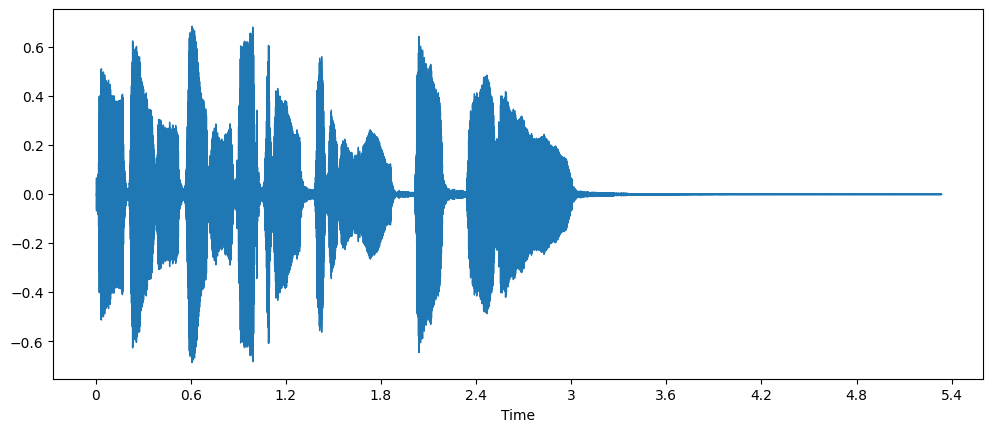

In [3]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

### Stereo and Mono

In audio, there are channels of audio. 
In mono audio, theres only one dimension of sound, in one channel.
But in stereo, there can be multiple. 
Mono is like listening with one ear.
Stereo eg: in movies theatres, theres surround sound. thats a multi channel audio, it is coming from various sources.


#### Why we need mono 
For our model, we are working on speech. 
Speech is from one single source, so we only need mono audio. 

If there are multiple channels for audio, it can cause ambiguity. So we need the array we have to be of a single dimension. 

the single dimension mono also requires less storage and processing.

### How to convert stereo to mono
add both and divide by 2

In librosa, the audio by default is in mono, so we dont need to necessarily convert it.

But syntax to convert is:

In [4]:
y_mono = librosa.to_mono(array)

#### Torchaudio
torchaudio does not automatically convert to mono, so we need to convert it

In [5]:
import torchaudio

#waveform, sr = torchaudio.load("audio.wav")

#mono_waveform = waveform.mean(dim=0, keepdim=True)

## Day 2

### MFCC
Mel Frequency Cepstral Coefficients.

#### Dividing into sections
MFCC divides the audio into sections of 25ms and they overlap. (convention)
We jump with a 10ms gap to the next frequency.
We are overlapping the sections to prevent data loss. 

#### Windowing
When we have a section, we perform "windowing",
In this process, we multiply each frame with a hamming window. 
THe hamming window is a bell shaped curve that cuts out the edges towards the ends of the frame. We do this to avoid unnecessary spikes that may add incorrect data to our model. 
No data is lost because the frames overlap, so in some frame the necessary part of the audio lies inside the hamming window.

If we do not window, then theres false spikes towards the ends, thats spectral leakage.

The first and last frames of the audio file will be skipped over because of the hamming window, so librosa by default adds 0 to the start of the initial frame, to prevent any data leaks. 

#### FFT
Fast Fourier Transform
A faster version of Fourier transform with O(n logn) time complexity

An audio fille is a mix of many different frequencies. All of these freqeuncies add up and make up the actual wave. 
All of these waves combined give the spectrum. 

The fourier transform helps us find out which all frequencies are present in the wave.

##### Interesting fact I found
In MFCC full form, Mel Frequency Cepstrum Coeffiencnts,
The word Cepstrum is actually a jambled version of spectrum. 

When you take the reverse of "spec" + trum, you get cepstrum.

The scients did it as a joke.

#### Mel Filterbank

In total, we will have a lot, way too many frequencies to calculate.
So we divide the frequencies into 26 sections by default. But in librosa we will divide into 128 sections.

Humans hear from 80Hz to 8khz. 
But we can differentiate the difference in frequencies in the lower end of the easier than in the higher end.
Like we can differentiate bw 200hz and 300hz easily, but not between 5500 and 5600.
The freq on the higher end are pretty same for us. 

After we divide the freq into 26 sections, we take the 13 sections with the most frequencies. 
We do this to speed up the process. Most of the data that is there after the top 13 frequencies is usually noise.

#### Logarithm
We dont hear sounds linearly. 
If a sound wave is 10x louder, it will approx only be 2x louder for us. 
So to shrink down numbers and make them easier for calculations, we take the log of the numbers.



## Waveform and Spectrogram

### Waveform
A waveform is a graph between the time and amplitude. 
It gives us a 2d graph in which we can find if sound exists, or there is silence.   
But it does not tell us about the sound, like its frequency and pitch

### Spectrogram
A spectrogram is a graph which shows time and frequency.
The amplitude of sound is shown using colors.  
It is more useful than waveform because it tell us what the soundwave actually consists of.

### Linear Scale vs Mel Scale
When we divide the frequencies into sections, we do not do it linearly.
Because humans dont hear linearly.

So we put more focus on the lower frequencies and stretch them more.  
ANd for higher frequencies, we squeeze more into the frequency range.

Mel scale also has lower frequency ranges.  
So processing is faster and we get more relevant data to what we humans actually hear.

### Waveform

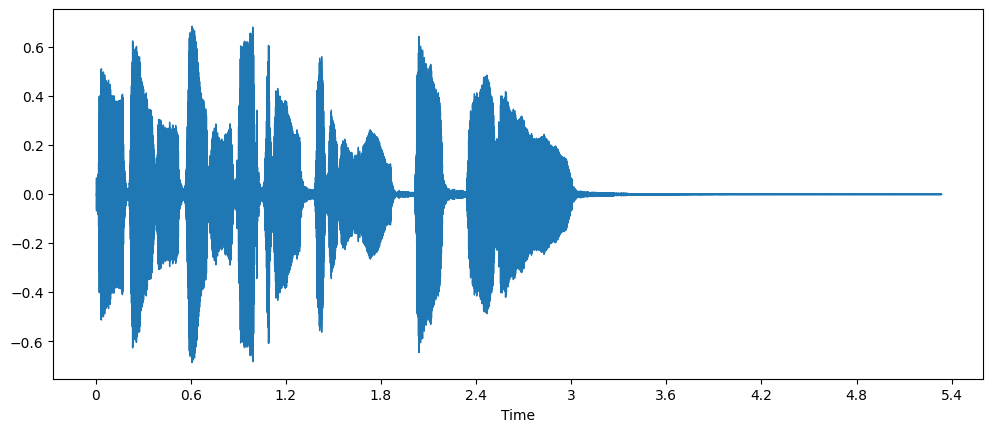

In [6]:
import librosa
import matplotlib.pyplot as plt
import librosa.display

# Load a sample sound that ships with librosa
array, sampling_rate = librosa.load(librosa.ex("trumpet"))

# Plot it
plt.figure().set_figwidth(12)
librosa.display.waveshow(array, sr=sampling_rate)

### Spectrum plot from HF course
This will compare the graph bw the amplitude and freqency.

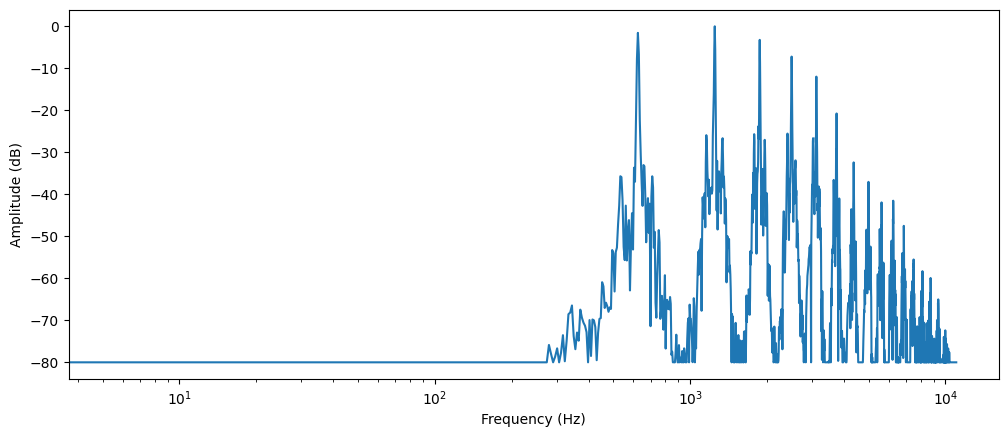

In [7]:
import numpy as np

dft_input = array[:4096]   # take only the first 4096 samples

# calculate the DFT
window = np.hanning(len(dft_input))
windowed_input = dft_input * window
dft = np.fft.rfft(windowed_input)

# get the amplitude spectrum in decibels
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

# get the frequency bins
frequency = librosa.fft_frequencies(sr=sampling_rate, n_fft=len(dft_input))

plt.figure().set_figwidth(12)
plt.plot(frequency, amplitude_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.xscale("log")

### Code for Spectogram

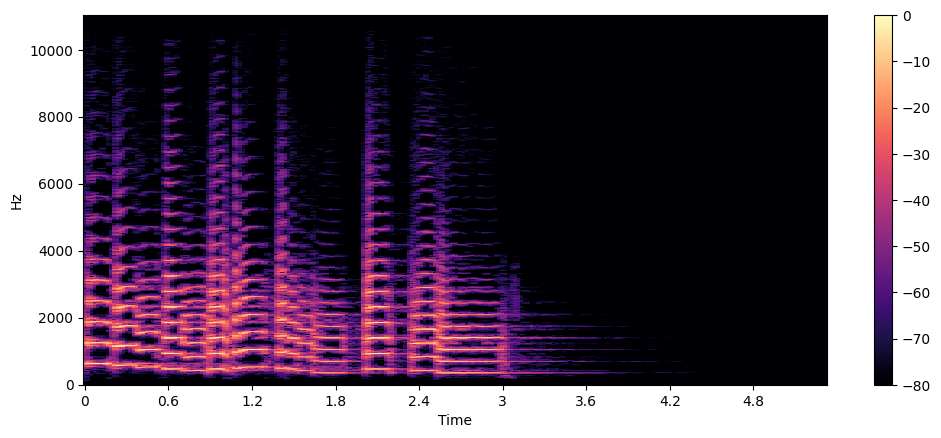

In [8]:
import numpy as np

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()

### Mel Spectrogram

We can see that the mel spectrogram has divided the frequencies in a diff way than the linear one.  
In the linear one, the upper portion was pretty unused, which is wasted potential.  
in the mel one, we can see how it is uniformly being used.  
Because we use frequencies of the lower end more, we need to pay more attention to that. It is more valueable to us than the higher portions.

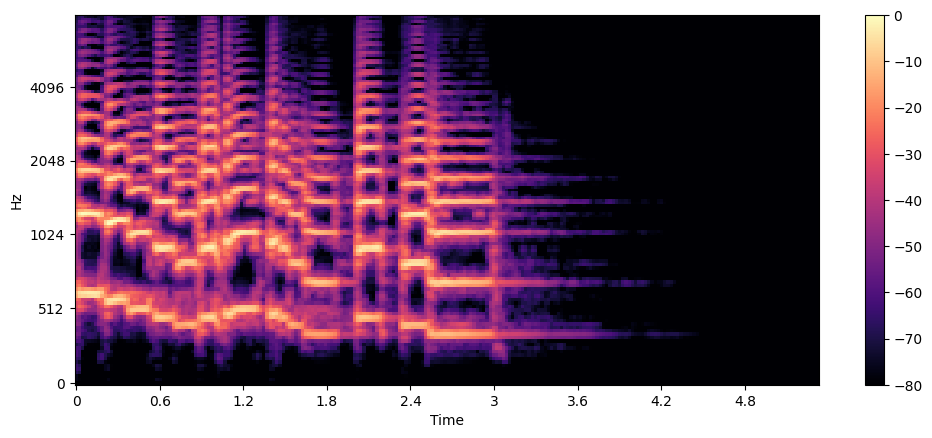

In [9]:
S = librosa.feature.melspectrogram(y=array, sr=sampling_rate, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sampling_rate, fmax=8000)
plt.colorbar()